## Problem Statement

---
- Forecast the traditional speed of tropical cyclones using LSTM, RNN and GRU 
- compare the performance visually

## Data Description

---
The dataset consists of cyclone trajectory records stored in CSV
files. Each file contains time-series observations such as:
- Latitude
- Longitude
- Wind speed / intensity

The task is a sequence-to-sequence regression problem:   
Given past timesteps → predict future intensity and track.

Models used are 
- LSTM
- GRU
- RNN

Import required libraries

In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

c:\Users\DS-31\Biswa_PG\.Rup\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Data loader class

In [2]:
class DataLoader:

    def __init__(self, path):
        self.path = path

    def load_data(self):

        files = [os.path.join(self.path, f)
                 for f in os.listdir(self.path)
                 if f.endswith(".csv")]

        dfs = []
        for f in files:
            df = pd.read_csv(f)

            lat = [c for c in df.columns if "lat" in c.lower()][0]
            lon = [c for c in df.columns if "lon" in c.lower()][0]
            time = [c for c in df.columns if "time" in c.lower() or "date" in c.lower()][0]

            temp = df[[time, lat, lon]].copy()
            temp.columns = ["TIME", "LAT", "LON"]

            temp["TIME"] = pd.to_datetime(temp["TIME"], errors="coerce")
            temp = temp.sort_values("TIME").dropna()

            # Compute translational speed (distance between consecutive points)
            temp["SPEED"] = np.sqrt(
                temp["LAT"].diff()**2 + temp["LON"].diff()**2
            )

            temp = temp.dropna()

            dfs.append(temp)

        return pd.concat(dfs, ignore_index=True)

    def preprocess(self, df):

        features = ["LAT", "LON", "SPEED"]

        self.mean = df[features].mean()
        self.std = df[features].std()

        df[features] = (df[features] - self.mean) / self.std

        X, y = [], []
        values = df[features].values

        for i in range(len(values) - seq_length):
            X.append(values[i:i+seq_length])
            y.append(values[i+seq_length][-1])  # predict SPEED only

        return np.array(X), np.array(y)


Model(s) Architectures

In [3]:
class SequenceModel:

    def __init__(self, model_type, input_shape):

        inputs = layers.Input(shape=input_shape)

        if model_type == "RNN":
            x = layers.SimpleRNN(64)(inputs)

        elif model_type == "LSTM":
            x = layers.LSTM(64)(inputs)

        elif model_type == "GRU":
            x = layers.GRU(64)(inputs)

        x = layers.Dense(32, activation="relu")(x)
        outputs = layers.Dense(1)(x)

        self.model = models.Model(inputs, outputs)

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate),
            loss="mse",
            metrics=["mae"]
        )

    def train(self, X_train, y_train, X_val, y_val):
        return self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=1
        )

    def predict(self, X):
        return self.model.predict(X)

Experiment class

In [4]:
class Experiment:

    def __init__(self):
        self.loader = DataLoader(data_path)

    def run(self):

        df = self.loader.load_data()
        X, y = self.loader.preprocess(df)

        split = int(0.8 * len(X))
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        histories = {}
        predictions = {}

        for model_type in ["RNN", "LSTM", "GRU"]:

            print(f"\nTraining {model_type}...")

            model = SequenceModel(model_type, X_train.shape[1:])
            history = model.train(X_train, y_train, X_test, y_test)

            y_pred = model.predict(X_test)

            histories[model_type] = history
            predictions[model_type] = y_pred

        self.plot_results(histories, y_test, predictions)

    # Visual comparison plot
    def plot_results(self, histories, y_test, predictions):

        # -------- loss comparison --------
        plt.figure(figsize=(10,5))
        for k, h in histories.items():
            plt.plot(h.history['val_loss'], label=k)

        plt.title("Validation Loss Comparison")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid()
        plt.show()

        # -------- MAE comparison --------
        plt.figure(figsize=(10,5))
        for k, h in histories.items():
            plt.plot(h.history['val_mae'], label=k)

        plt.title("Validation MAE Comparison")
        plt.xlabel("Epochs")
        plt.ylabel("MAE")
        plt.legend()
        plt.grid()
        plt.show()

        # -------- PREDICTION VS TRUE --------
        plt.figure(figsize=(10,5))
        plt.plot(y_test[:100], label="True Speed")

        for k, pred in predictions.items():
            plt.plot(pred[:100], label=k)

        plt.title("Predicted vs Actual Speed")
        plt.xlabel("Time Steps")
        plt.ylabel("Normalized Speed")
        plt.legend()
        plt.grid()
        plt.show()


In [5]:
seq_length = 10
batch_size = 32
epochs = 25
learning_rate = 0.0005
data_path = r"C:\Users\DS-31\Biswa_PG\Biswa_PG4\DL\attachments"   


Training RNN...
Epoch 1/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6461 - mae: 0.4792 - val_loss: 0.1357 - val_mae: 0.2860
Epoch 2/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3778 - mae: 0.3029 - val_loss: 0.0892 - val_mae: 0.2179
Epoch 3/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2893 - mae: 0.2562 - val_loss: 0.0665 - val_mae: 0.1755
Epoch 4/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2534 - mae: 0.2477 - val_loss: 0.0705 - val_mae: 0.1788
Epoch 5/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2279 - mae: 0.2385 - val_loss: 0.0764 - val_mae: 0.1947
Epoch 6/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2153 - mae: 0.2395 - val_loss: 0.0636 - val_mae: 0.1700
Epoch 7/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2030 - mae: 0.2341 - val_loss: 0.0586 - val_mae: 0.1669
Epoch 8/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1970 - mae: 0.2315 - val_loss: 0.0611 - val_mae: 0.1663
Epoch 9/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - los

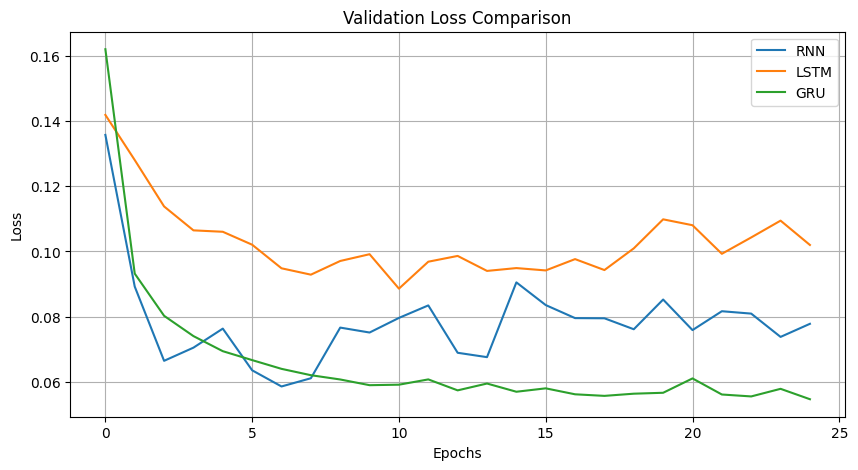

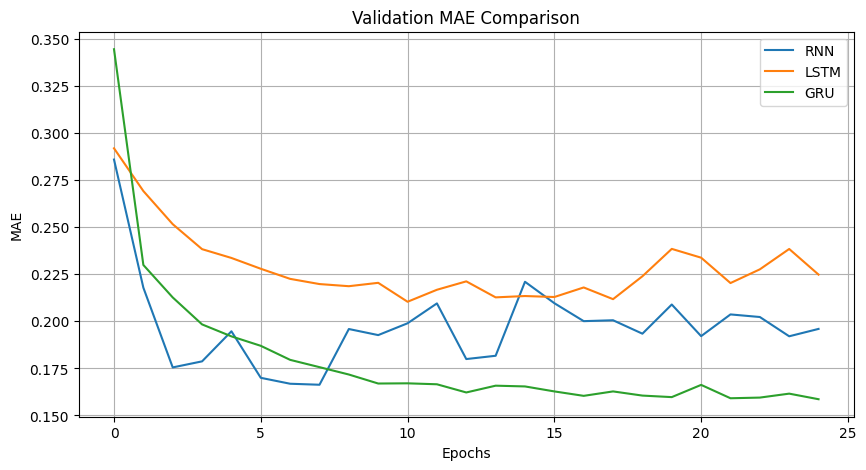

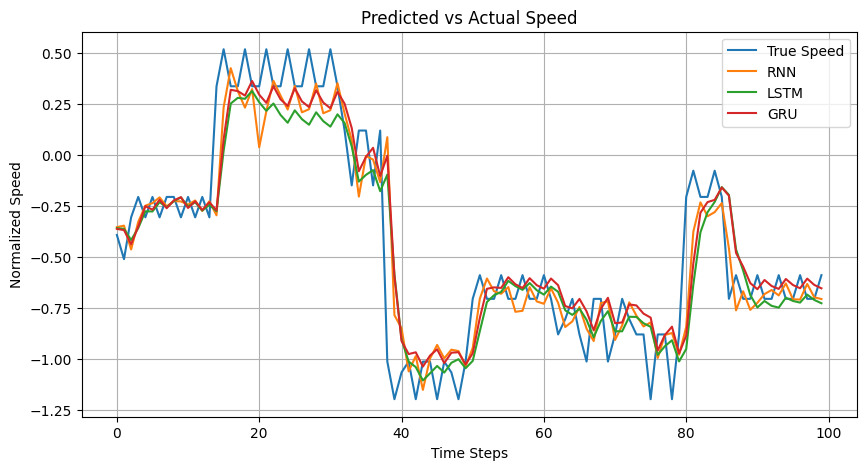

In [6]:
code = Experiment()
code.run()